In [1]:
import importlib
import SelfCal
importlib.reload(SelfCal.MapHelper)
importlib.reload(SelfCal.PipelineWrapper)
importlib.reload(SelfCal.MakeMap)

AttributeError: module 'SelfCal' has no attribute 'MapHelper'

In [2]:
import os
from SelfCal import PipelineWrapper
from SelfCal.MakeMap import load_reproj_file
from SelfCal.MapHelper import bit_to_bool, bin2d_cv, upscale2d

from astropy.io.votable import parse, parse_single_table
from astropy.io import fits
from astropy.wcs import WCS
import glob
from tqdm import tqdm
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib as mpl
from functools import partial
mpl.rcParams['figure.dpi'] = 200


In [3]:
exp_dir = '/data1/Euclid/OTF/NISP/'
exposure_list = glob.glob(exp_dir + '*_Y*.fits')
dq_ext_list = (np.arange(0,16)*3+3)
sci_ext_list = (np.arange(0,16)*3+1)


config = {}
config['output_dir'] = '/mnt/md124/thomasli/selfcal/outputs/'
config['run_name'] = f'EDFN_Y_6p0arcsec'
config['resolution_arcsec'] = 6.0

In [13]:
rr = PipelineWrapper.Reprojector(config, exposure_list=exposure_list)
rr.define_reference(padding_pixels=100, use_ext=[1, 10, 37, 46])

rr.run_reproject(max_workers=150, reproj_func='exact', padding_percentage=0.05, 
                    sci_ext_list=sci_ext_list, 
                    dq_ext_list=dq_ext_list, 
                    exp_idx_list=np.arange(0, len(exposure_list)), 
                    det_idx_list=np.arange(0,16),
                    replace_existing=False,
                 reproject_kwargs={'parallel': 2}
                )

Reference WCS not found at /mnt/md124/thomasli/selfcal/outputs/EDFN_Y_6p0arcsec/ref.fits. Creating a new reference frame.
Defining optimal celestial WCS...


Loading corner WCS: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 904/904 [01:07<00:00, 13.44it/s]


Reference frame FITS saved to: /mnt/md124/thomasli/selfcal/outputs/EDFN_Y_6p0arcsec/ref.fits
Reference WCS saved to /mnt/md124/thomasli/selfcal/outputs/EDFN_Y_6p0arcsec/ref.fits
Mosaic shape: (4022, 3929)
Mosaic WCS: WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 269.84699816649936 65.98859911120327 
CRPIX : 2038.7888950186657 1997.1758908569968 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.0016666666666666666 0.0016666666666666666 
NAXIS : 0  0
Starting batch reprojection. Output will be saved to: /mnt/md124/thomasli/selfcal/outputs/EDFN_Y_6p0arcsec/reprojected


Reprojecting frames: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 14464/14464 [41:25<00:00,  5.82it/s]


Batch reprojection completed. 14464 frames successfully processed out of 14464.
Reprojection completed in 2494.86 seconds.


In [ ]:
# calib_set = sorted(glob.glob('/mnt/md124/thomasli/selfcal/outputs/EDFN_Y_0p9arcsec/reprojected/*.h5'))
# coadd_set = sorted(glob.glob('/mnt/md124/thomasli/selfcal/outputs/EDFN_Y_0p3arcsec/reprojected/*.h5'))

# calib_set_basenames = [os.path.basename(f) for f in calib_set]
# coadd_set_basenames = [os.path.basename(f) for f in coadd_set]
# disjoint = list(set(calib_set_basenames) ^ set(coadd_set_basenames))

# for f in calib_set:
#     if os.path.basename(f) in disjoint:
#         print(f"File {os.path.basename(f)} is disjoint, removing file.")
#         os.remove(f)

# for f in coadd_set:
#     if os.path.basename(f) in disjoint:
#         print(f"File {os.path.basename(f)} is disjoint, removing file.")
#         os.remove(f)

# rr.get_reproj_files()
# reproj_list = sorted(rr.reproj_list)
# bad_list = []
# for f in tqdm(reproj_list):
#     try:
#         with h5py.File(f, 'r') as hf:
#             continue
#     except OSError:
#         print(f'Found corrupted file {f}')
#         bad_list.append(f)

# for f in bad_list:
#     os.remove(f)

In [4]:
def compute_chunk_edges(det_shape, chunk_size):
    '''Split detector into chunks and return edge of chunks'''
    det_h, det_w = det_shape
    chunk_h, chunk_w = chunk_size
    y_edges = np.arange(0, det_h + 1, chunk_h)
    x_edges = np.arange(0, det_w + 1, chunk_w)
    
    return x_edges, y_edges

def make_chunk_map(det_shape, chunk_size):
    '''Make a chunk map for the detector'''
    x_edges, y_edges = compute_chunk_edges(det_shape, chunk_size)
    chunk_map = np.zeros(det_shape, dtype=int)

    chunk_id = 0

    for j in range(len(y_edges)-1):
        y_low = y_edges[j]
        y_high = y_edges[j+1]
        for i in range(len(x_edges)-1):
            x_low = x_edges[i]
            x_high = x_edges[i+1]
            chunk_map[y_low:y_high, x_low:x_high] = chunk_id

            chunk_id += 1
    return chunk_map

def make_square_chunk_map(n_chunks_per_side, det_shape=(2040, 2040)):
    '''Make a square chunk map for the detector'''
    det_h, det_w = det_shape
    chunk_h = det_h // n_chunks_per_side
    chunk_w = det_w // n_chunks_per_side
    return make_chunk_map(det_shape, (chunk_h, chunk_w))

def estimate_memory_usage(sparse_matrix):
    total_bytes = sparse_matrix.data.nbytes + sparse_matrix.coords[0].nbytes + sparse_matrix.coords[1].nbytes
    print(f'Total memory usage: {total_bytes / (1024**3)} GB')  # Convert to GB

In [117]:
# import multiprocessing as mp
# from astropy.coordinates import SkyCoord
# from astropy.io import fits
# from astropy.wcs import WCS
# from tqdm import tqdm
# from SelfCal.MakeMap import load_reproj_file

# def process_reproj(args):
#     """Worker function to process a single reproj file."""
#     reproj_path, det_idx = args
#     try:
#         file_path = load_reproj_file(reproj_path, fields=['file_path'])['file_path']
#         with fits.open(file_path) as hdul:
#             hdr = hdul[det_idx*3 + 1].header
#             wcs = WCS(hdr)
#             center_x = hdr['NAXIS1'] / 2
#             center_y = hdr['NAXIS2'] / 2
#             return wcs.pixel_to_world(center_x, center_y)
#     except Exception as e:
#         print(f"Error processing {reproj_path}: {e}")
#         return None

# cc = PipelineWrapper.Calibrator(config)

# # Preparation of arguments
# tasks = list(zip(cc.reproj_list, cc.det_idx_list))

# # Parallel execution
# with mp.Pool(processes=20) as pool:
#     sc_list = list(tqdm(pool.imap(process_reproj, tasks), total=len(tasks)))

# nep_ra, nep_dec = 270, 66.5
# nep_sc = SkyCoord(nep_ra, nep_dec, unit='deg')
# radius = 0.7

# in_mask = []
# for sc in tqdm(sc_list):
#     sep = sc.separation(nep_sc)
#     if sep.degree < radius:
#         in_mask.append(True)
#     else:
#         in_mask.append(False)

# cc.reproj_list = [item for i,item in enumerate(cc.reproj_list) if in_mask[i]]

# with open('/home/thomasli/spherex/selfcal/misc/reproj_list_nep_6p0.txt', 'w') as f:
#     for item in cc.reproj_list:
#         f.write(f"{item}\n")

In [5]:
exp_dir = '/data1/Euclid/OTF/NISP/'
exposure_list = glob.glob(exp_dir + '*_Y*.fits')
dq_ext_list = (np.arange(0,16)*3+3)
sci_ext_list = (np.arange(0,16)*3+1)

config = {}
config['output_dir'] = '/mnt/md124/thomasli/selfcal/outputs/'
config['run_name'] = f'EDFN_Y_6p0arcsec'
config['resolution_arcsec'] = 0.9

cc = PipelineWrapper.Calibrator(config)


AttributeError: 'dict' object has no attribute 'reproj_dir'

In [155]:
def postprocess_func(sub_data, sub_weight):
    return np.full_like(sub_data, np.nanmedian(sub_data)), sub_weight

In [ ]:
header_list = []
native_zp = []
det_idices = []
exp_idices = []

for reproj_path in tqdm(cc.reproj_list):
    h5_data = load_reproj_file(reproj_path, fields=['file_path','sub_data'])
    exp_path = h5_data['file_path']
    det_idx = h5_data['det_idx']
    exp_idx = h5_data['exp_idx']
    det_ext = det_idx*3 + 1
    hdul = fits.open(exp_path)
    ZPAB = hdul[det_ext].header['ZPAB']
    MAGZEROP = hdul[det_ext].header['MAGZEROP']
    native_zp.append(ZPAB)
    det_idices.append(det_idx)
    exp_idices.append(exp_idx)
    header_list.append(hdul[det_ext].header)
native_zp = np.array(native_zp)
ref_zp = np.median(native_zp)
flux_scale = 10**(-0.4 * (native_zp - ref_zp))

# flux_scale_dict = {}
# for exp_idx, det_idx, scale in zip(exp_idices, det_idices, flux_scale):
#     flux_scale_dict[(exp_idx, det_idx)] = scale
    

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14464/14464 [02:17<00:00, 105.37it/s]


In [321]:
header_list[0]

XTENSION= 'IMAGE   '           / IMAGE extension                                
BITPIX  =                  -32 / number of bits per data pixel                  
NAXIS   =                    2 / number of data axes                            
NAXIS1  =                 2040 / length of data axis 1                          
NAXIS2  =                 2040 / length of data axis 2                          
PCOUNT  =                    0 / required keyword; must = 0                     
GCOUNT  =                    1 / required keyword; must = 1                     
EXTNAME = 'DET11.SCI'                                                           
DET_ID  = '11      '           / Detector ID, e.g. '13'                         
SCEINDEX=                    3 / SCE ID from raw header                         
SCA_ID  = '18453   '           / SCA full name given by NASA                    
BUNIT   = 'ELECTRON'           / physical units of the array values             
RON_DET =                   

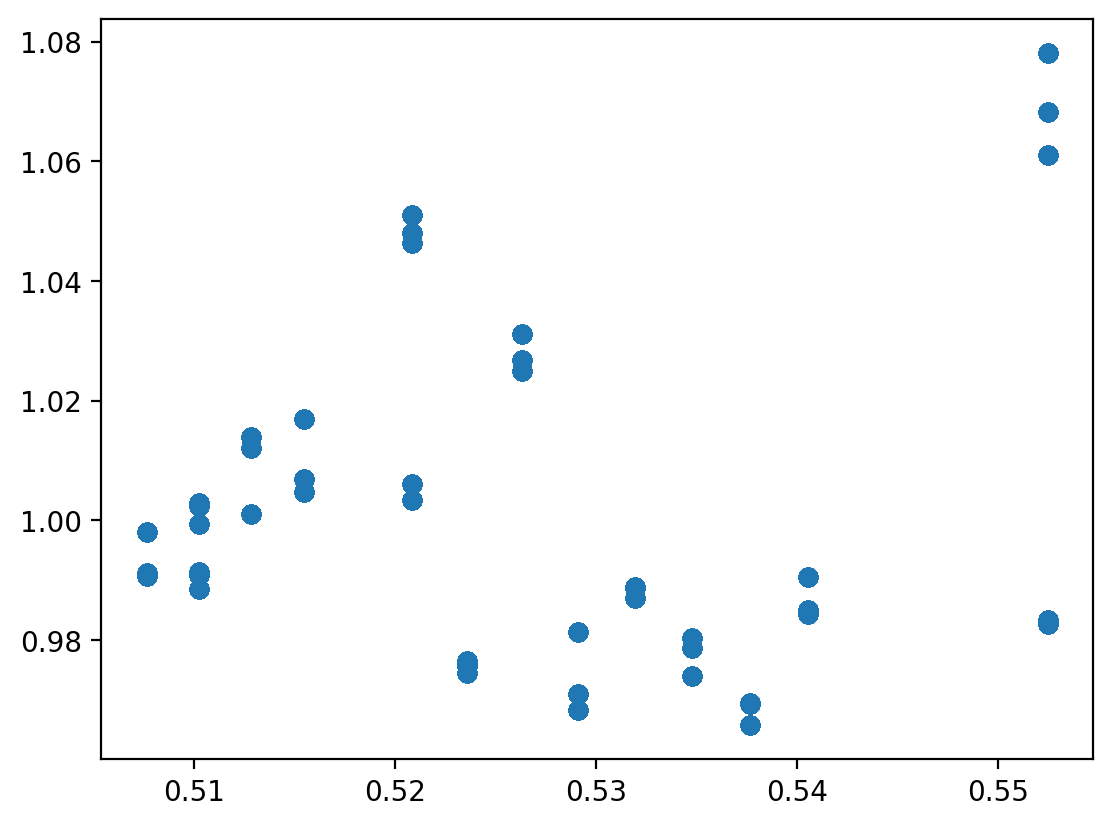

In [339]:
x = [h['GAIN'] for h in header_list]
y = [h['PHRELDT'] for h in header_list]
plt.scatter(x, y)

In [335]:
scale = (y-np.median(y))/np.median(y)+1

In [336]:
scale

array([0.99218066, 0.97193208, 1.01329089, ..., 0.97193208, 0.96699841,
       1.00262467], shape=(14464,))

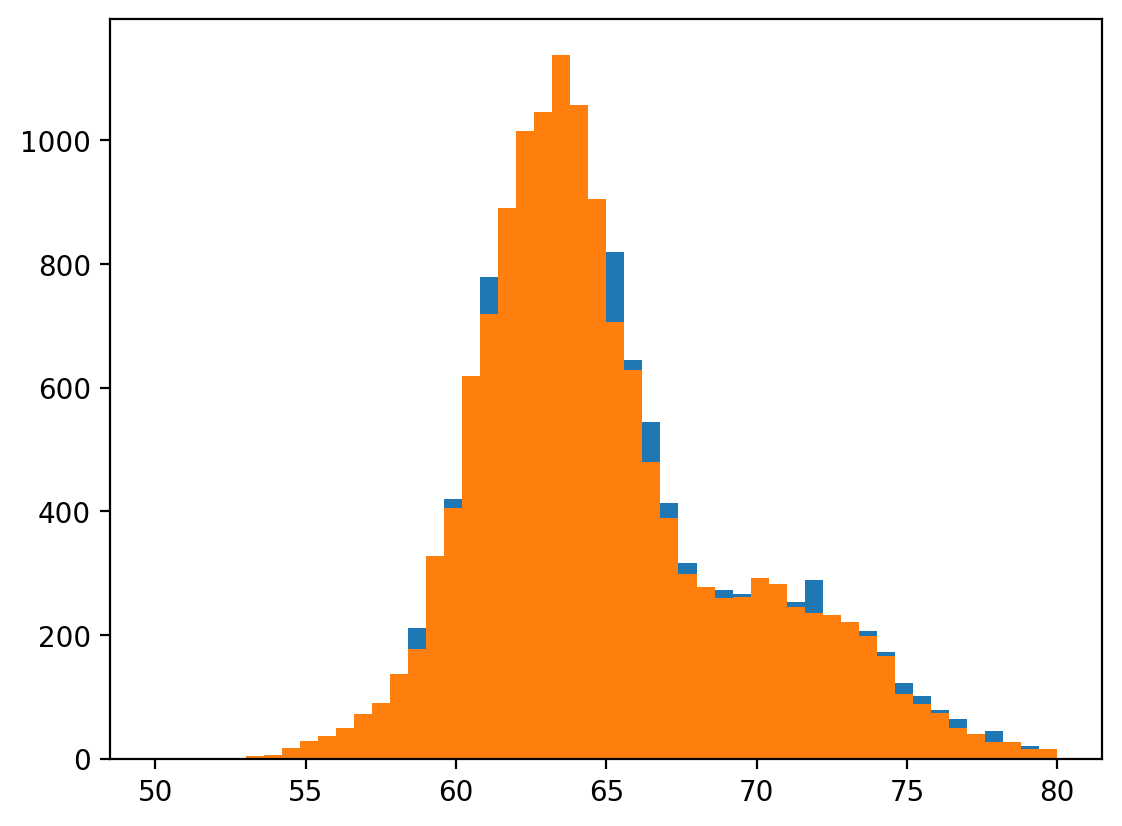

In [338]:
_ = plt.hist(np.array(median_sub_data), range=(50,80), bins=50)
_ = plt.hist(np.array(median_sub_data)/scale, range=(50,80), bins=50)

In [292]:
def apply_scale(local, flux_scale_dict):
    exp_idx = local['exp_idx']
    det_idx = local['det_idx']
    sub_data = local['sub_data']
    scale = flux_scale_dict[(exp_idx, det_idx)]
    sub_data *= scale
    return sub_data

preprocess_func = partial(apply_scale, flux_scale_dict=flux_scale_dict)


In [408]:
# with open('/home/thomasli/spherex/selfcal/misc/reproj_list_nep.txt', 'r') as f:
#     cc.reproj_list = [line.strip() for line in f.readlines()]

chunk_map = make_square_chunk_map(n_chunks_per_side=4, det_shape=(2040, 2040))

cc.setup_lsqr(
    apply_mask=True, 
    apply_weight=False, 
    chunk_map=chunk_map,
    det_valid_mask=np.ones((2040, 2040)),
    max_workers=40, 
    outlier_thresh=0.5,
    ignore_list=[11,15],
    oversample_factor=1,
    batch_size=50,
    reg_weight=0,
    # preprocess_func=pre_process_func,
    # postprocess_func=postprocess_func
    )

estimate_memory_usage(cc.A)

cc.apply_lsqr(x0=None, atol=1e-80, btol=1e-80, damp=1e-5, iter_lim=100, precondition=False)

Processing 14464 items in 290 batches...


Building A, b matrix: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 290/290 [00:44<00:00,  6.55it/s]


LSQR setup completed in 69.43 seconds.
Total memory usage: 1.0540934912860394 GB
Solving least squares for 16033862 unknowns with 47090464 equations.
 
LSQR            Least-squares solution of  Ax = b
The matrix A has 47090464 rows and 16033862 columns
damp = 1.00000000000000e-05   calc_var =        0
atol = 1.00e-80                 conlim = 1.00e+08
btol = 1.00e-80               iter_lim =      100
 
   Itn      x[0]       r1norm     r2norm   Compatible    LS      Norm A   Cond A
     0  0.00000e+00   4.434e+05  4.434e+05    1.0e+00  3.4e-05
     1  0.00000e+00   9.192e+04  9.192e+04    2.1e-01  9.1e-01   1.5e+01  1.0e+00
     2  0.00000e+00   2.749e+04  2.749e+04    6.2e-02  5.8e-01   2.1e+01  2.0e+00
     3  0.00000e+00   1.395e+04  1.395e+04    3.1e-02  3.0e-01   2.6e+01  3.1e+00
     4  0.00000e+00   1.157e+04  1.157e+04    2.6e-02  1.3e-01   3.0e+01  4.2e+00
     5  0.00000e+00   1.106e+04  1.106e+04    2.5e-02  7.3e-02   3.3e+01  5.4e+00
     6  0.00000e+00   1.076e+04  1.076e+

In [23]:
cal_path = cc.save_calibration(cal_file=f'cal_Y_full_4x4_6arcsec.h5')

Calibration saved to /mnt/md124/thomasli/selfcal/outputs/EDFN_Y_6p0arcsec/calibration/cal_Y_full_4x4_6arcsec.h5


In [36]:
cc.O.shape

(14464, 1)

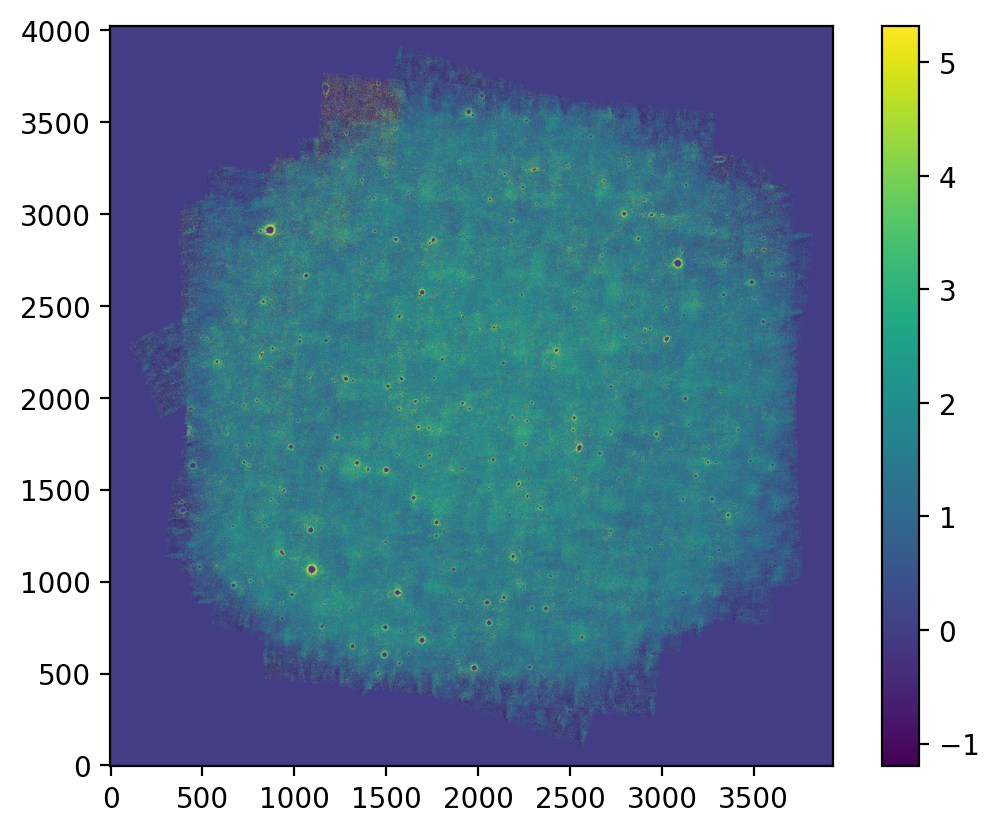

In [409]:
low, med, high = np.percentile(cc.S[np.nonzero(cc.S)], [1, 50, 99])
plt.imshow((cc.S), vmin=low, vmax=high, origin='lower')#[12000:17500,10000:15500]
plt.colorbar()

In [ ]:
# frame_index = 15

# single_offset = cc.O[frame_index][chunk_map]

# reproj_path = cc.reproj_list[frame_index]
# det_idx = int(reproj_path.split('_')[-1][:-3])
# file_path = load_reproj_file(reproj_path, fields=['file_path'])['file_path']
# hdul = fits.open(file_path)
# sci_data = hdul[det_idx*3+1].data
# bitmask = hdul[det_idx*3+3].data
# boolmask = bit_to_bool(bitmask, ignore_list=[11, 15])

# fig, axes = plt.subplots(1,3, figsize=(8,4))

# offset_min, offset_max = np.percentile(single_offset[single_offset!=0]-np.min(single_offset[single_offset!=0]), [1, 95])
# axes[0].imshow(single_offset-np.min(single_offset[single_offset!=0]), origin='lower', cmap='viridis', vmin=offset_min, vmax=offset_max)
# axes[1].imshow(sci_data, origin='lower', cmap='viridis', norm=LogNorm(*np.percentile(sci_data, [5, 90])))
# axes[2].imshow(boolmask, origin='lower', cmap='gray')

In [405]:
from SelfCal.MapHelper import find_outliers

frame_index = 15

single_offset = cc.O[frame_index][chunk_map]

reproj_path = cc.reproj_list[frame_index]
det_idx = int(reproj_path.split('_')[-1][:-3])
file_path = load_reproj_file(reproj_path, fields=['file_path'])['file_path']
hdul = fits.open(file_path)
sci_data = hdul[det_idx*3+1].data
out = find_outliers(sci_data, threshold=2)

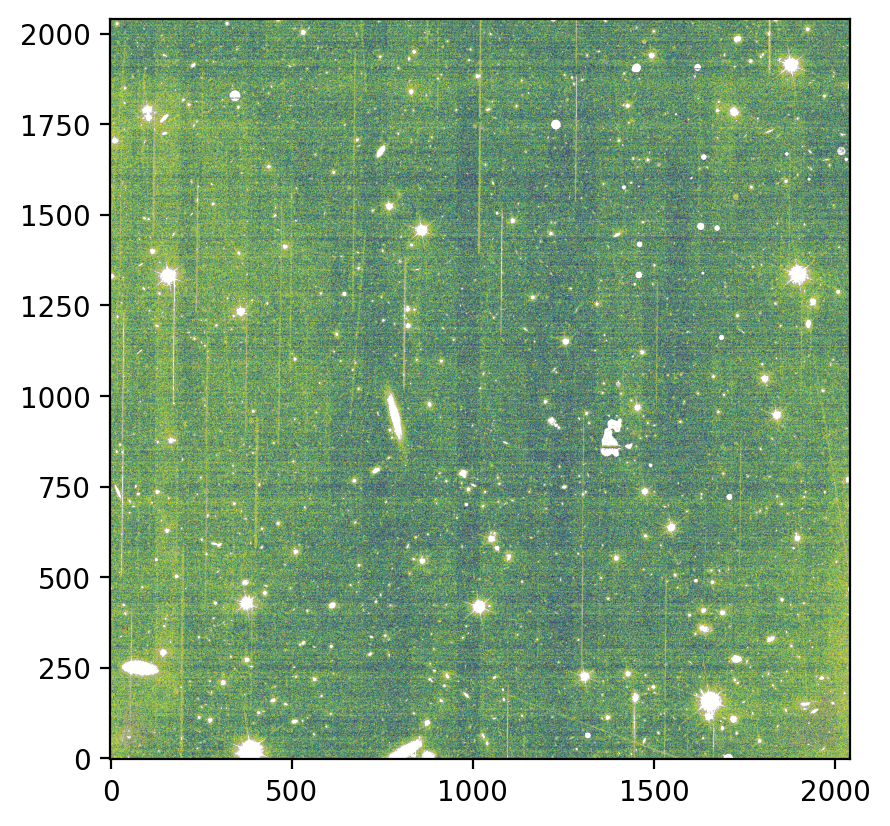

In [406]:
masked_sci = np.where(out, np.nan, sci_data)
vmin, vmax = np.nanpercentile(masked_sci, [5, 85])
plt.imshow(masked_sci, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)

In [344]:
global_mean_offset = cc.O[:,0].copy()

In [ ]:
cc2 = PipelineWrapper.Calibrator(config)
# with open('/home/thomasli/spherex/selfcal/misc/reproj_list_nep.txt', 'r') as f:
#     cc2.reproj_list = [line.strip() for line in f.readlines()]

chunk_map2 = make_square_chunk_map(n_chunks_per_side=40, det_shape=(2040, 2040))

cc2.setup_lsqr(
    apply_mask=True, 
    apply_weight=False, 
    chunk_map=chunk_map2,
    det_valid_mask=np.ones((2040, 2040)),
    max_workers=30, 
    outlier_thresh=0.5,
    ignore_list=[11,15],
    oversample_factor=1,
    batch_size=20,
    reg_weight=0.1,
    mean_offsets=None,#global_mean_offset
    )

print('Memory usage:')
total_bytes = cc2.A.data.nbytes + cc2.A.coords[0].nbytes + cc2.A.coords[1].nbytes
print(total_bytes / (1024**3), 'GB')

cc2.apply_lsqr(x0=None, atol=1e-80, btol=1e-80, damp=1e-5, iter_lim=100, precondition=False)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14464/14464 [00:00<00:00, 822127.24it/s]

Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/EDFN_Y_6p0arcsec/ref.fits
Pre-computing adjacency matrix...
Processing 14464 items in 724 batches...



Building A, b matrix: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 724/724 [01:34<00:00,  7.68it/s]


LSQR setup completed in 121.11 seconds.
Memory usage:
2.7753701210021973 GB
Solving least squares for 38944838 unknowns with 92218144 equations.
 
LSQR            Least-squares solution of  Ax = b
The matrix A has 92218144 rows and 38944838 columns
damp = 1.00000000000000e-05   calc_var =        0
atol = 1.00e-80                 conlim = 1.00e+08
btol = 1.00e-80               iter_lim =      100
 
   Itn      x[0]       r1norm     r2norm   Compatible    LS      Norm A   Cond A
     0  0.00000e+00   4.434e+05  4.434e+05    1.0e+00  7.1e-06
     1  0.00000e+00   1.341e+05  1.341e+05    3.0e-01  7.8e-01   3.3e+00  1.0e+00
     2  0.00000e+00   7.023e+04  7.023e+04    1.6e-01  4.8e-01   4.5e+00  2.1e+00
     3  0.00000e+00   4.548e+04  4.548e+04    1.0e-01  3.5e-01   5.5e+00  3.3e+00
     4  0.00000e+00   3.280e+04  3.280e+04    7.4e-02  2.7e-01   6.4e+00  4.7e+00
     5  0.00000e+00   2.526e+04  2.526e+04    5.7e-02  2.3e-01   7.2e+00  6.2e+00
     6  0.00000e+00   2.033e+04  2.033e+04   

In [47]:
cal_path = cc.save_calibration(cal_file=f'cal_Y_test.h5')

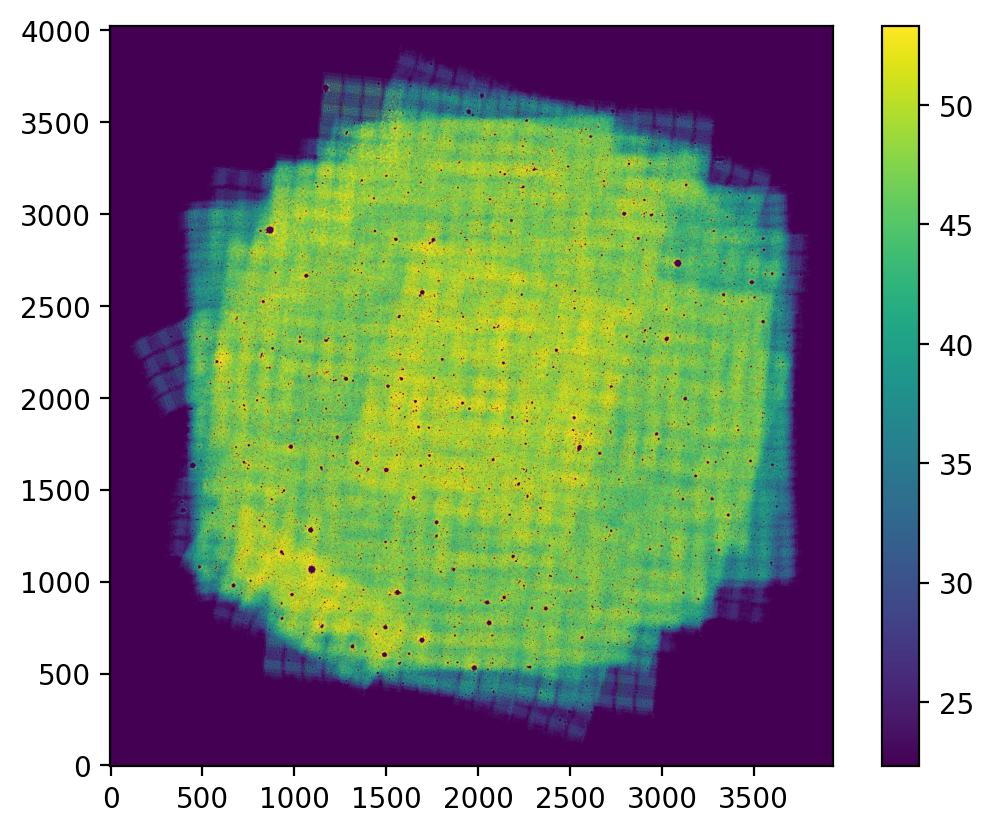

In [365]:
low, med, high = np.percentile(cc2.S[np.nonzero(cc2.S)], [1, 50, 99])
plt.imshow((cc2.S), vmin=low, vmax=high, origin='lower')#[12000:17500,10000:15500]
plt.colorbar()

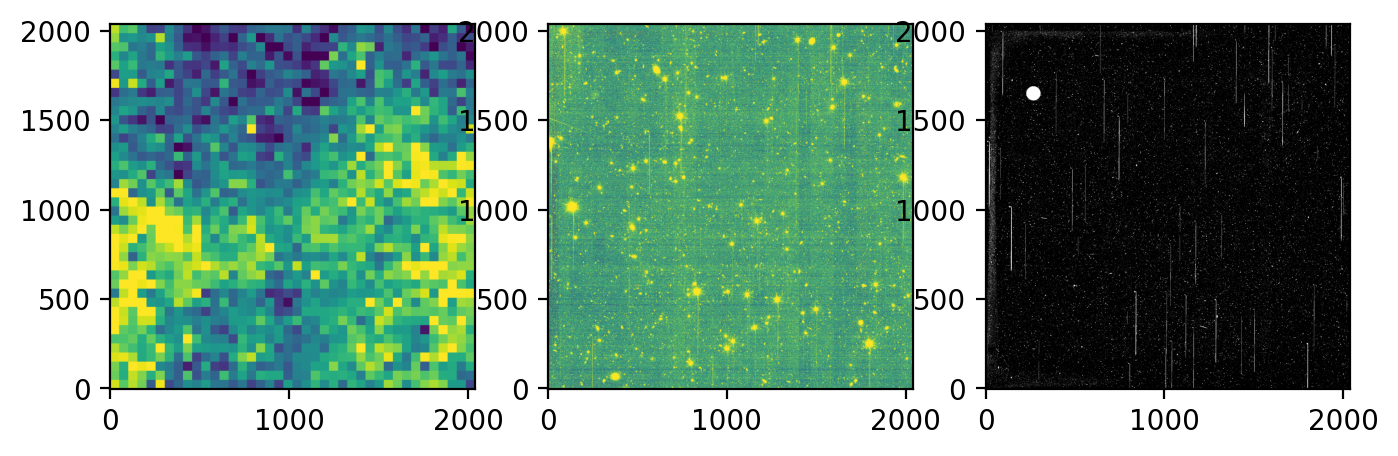

In [366]:
frame_index = 10

single_offset = cc2.O[frame_index][chunk_map2]

reproj_path = cc2.reproj_list[frame_index]
det_idx = int(reproj_path.split('_')[-1][:-3])
file_path = load_reproj_file(reproj_path, fields=['file_path'])['file_path']
hdul = fits.open(file_path)
sci_data = hdul[det_idx*3+1].data
bitmask = hdul[det_idx*3+3].data
boolmask = bit_to_bool(bitmask, ignore_list=[11, 15])

fig, axes = plt.subplots(1,3, figsize=(8,4))

offset_min, offset_max = np.percentile(single_offset[single_offset!=0]-np.min(single_offset[single_offset!=0]), [1, 95])
axes[0].imshow(single_offset-np.min(single_offset[single_offset!=0]), origin='lower', cmap='viridis', vmin=offset_min, vmax=offset_max)
axes[1].imshow(sci_data, origin='lower', cmap='viridis', norm=LogNorm(*np.percentile(sci_data, [1, 95])))
axes[2].imshow(boolmask, origin='lower', cmap='gray')

In [169]:
O = cc.O
all_offset = O.reshape(len(O),40,40)

In [185]:
select_i = [i for i, f in enumerate(cc.reproj_list) if 'det_14' in f]

In [247]:
# select_offset = all_offset[select_i]
# # Sort offsets by median offset value, choose 25th, 50th, 75th percentiles
# median = np.median(select_offset, axis=(1,2))
# sorted_indices = np.argsort(median)
# sorted_offsets = select_offset[sorted_indices]

# low_off = sorted_offsets[len(sorted_offsets)//4]
# med_off = sorted_offsets[len(sorted_offsets)//2]
# high_off = sorted_offsets[3*len(sorted_offsets)//4]

# fig, axes = plt.subplots(1, 3, figsize=(12,4))
# vmin, vmax = np.percentile(O, [20, 80])
# axes[0].imshow(low_off, vmin=vmin, vmax=vmax)
# axes[1].imshow(med_off, vmin=vmin, vmax=vmax)
# axes[2].imshow(high_off, vmin=vmin, vmax=vmax)


# cbar = fig.colorbar(axes[0].images[0], ax=axes, orientation='vertical', fraction=.1)

In [118]:
back_dir = '/data1/Euclid/OTF/Background/'
back_files = glob.glob(back_dir + '*.fits')
def retrive_background(reproj_path):
    det_idx = int(reproj_path.split('_')[-1][:-3])
    det_ext = det_idx*3 + 1
    exp_path = load_reproj_file(reproj_path, fields=['file_path'])['file_path']
    exp_id = os.path.basename(exp_path).split('_')[3]
    back_path = [f for f in back_files if exp_id in f]
    if len(back_path) == 0:
        return None
    else:
        back_path = back_path[0]
        with fits.open(back_path) as hdul:
            back_data = hdul[det_ext].data
        return back_data

In [119]:
from SelfCal.MapHelper import bin2d_cv

In [121]:
reproj_list = cc.reproj_list
back_list = []
for p in tqdm(reproj_list):
    try:
        back_list.append(retrive_background(p))
    except IndexError:
        back_list.append(0)

  0%|                                                                                                                              | 0/1067 [00:00<?, ?it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1067/1067 [04:24<00:00,  4.03it/s]


In [ ]:
binned_background = np.mean(background, axis=(1, 2))#bin2d_cv(background, 204)

In [126]:
back_list = [np.mean(b) for b in tqdm(back_list)]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1067/1067 [01:01<00:00, 17.31it/s]


In [ ]:
hdul=fits.open('/data1/Euclid/OTF/Background/EUC_NIR_W-CAL-IMAGE-BKG_Y-65774-92_20240106T163816.031317Z.fits')
plt.imshow(hdul[46].data, vmin=55, vmax=65)
plt.colorbar()

FileNotFoundError: [Errno 2] No such file or directory: '/data1/Euclid/OTF/Background/EUC_NIR_W-CAL-IMAGE-BGK_Y-2083-0_20240706T112731.939062Z.fits'

In [2]:
# plt.imshow(med_off-low_off)
# plt.colorbar()

In [44]:
cal_data = sci_data-single_offset+np.mean(single_offset[boolmask])
mask_data = np.where(~boolmask, cal_data, np.nan)
plt.imshow(mask_data, origin='lower', cmap='viridis', norm=LogNorm(*np.percentile(sci_data, [1, 95])))
plt.colorbar()

In [76]:
# low, med, high = np.percentile(cc2.S[np.nonzero(cc2.S)], [5, 50, 95])
# plt.imshow((cc2.S)[13000:17000,11000:15000], vmin=low, vmax=high)
# plt.colorbar()

In [ ]:
from scipy.interpolate import RectBivariateSpline
def mean_preserving_spline_2d(x_edges, y_edges, z_means, kx=3, ky=3):
    """
    Generates a mean-preserving spline function f(x, y) based on 2D grid edges
    and the average value z_mean in each rectangular cell.

    The function f(x, y) is constructed as the mixed partial derivative of a 
    bicubic spline F(x, y), where F(x, y) is the double integral of f(x, y).

    Parameters
    ----------
    x_edges : array_like, shape (N+1,)
        The edges of the bins along the x-axis.
    y_edges : array_like, shape (M+1,)
        The edges of the bins along the y-axis.
    z_means : array_like, shape (N, M)
        The mean value of the function within each rectangular bin.
    kx, ky : int, optional
        The degrees of the spline in x and y directions. Default is 3 (bicubic).
        
    Returns
    -------
    f_spline : callable
        A function f(x, y, grid=False) that evaluates the interpolated density.
        - If grid=True, evaluates on the grid spanned by x and y vectors.
        - If grid=False, evaluates at coordinates (x, y).
    """
    x_edges = np.asarray(x_edges, dtype=float)
    y_edges = np.asarray(y_edges, dtype=float)
    z_means = np.asarray(z_means, dtype=float)

    # 1. Validation
    if x_edges.shape[0] != z_means.shape[0] + 1:
        raise ValueError("len(x_edges) must be len(z_means) + 1 (rows)")
    if y_edges.shape[0] != z_means.shape[1] + 1:
        raise ValueError("len(y_edges) must be z_means.shape[1] + 1 (cols)")

    # 2. Compute Interval Areas (Volumes)
    # dx: (N,) -> column vector (N, 1)
    # dy: (M,) -> row vector (1, M)
    dx = np.diff(x_edges)
    dy = np.diff(y_edges)
    
    # Calculate volume of each cell: z_mean * dx * dy
    # Broadcasting: (N, 1) * (1, M) * (N, M)
    cell_volumes = z_means * dx[:, None] * dy[None, :]

    # 3. Compute Cumulative Integrals (2D Cumulative Sum)
    # The integral at (x0, y0) is 0.
    # The integral at (xi, yj) is sum of volumes in rect defined by [0:i, 0:j]
    integral_grid = np.zeros((len(x_edges), len(y_edges)))
    
    # cumsum over x (axis 0), then over y (axis 1)
    cumulative_volumes = np.cumsum(np.cumsum(cell_volumes, axis=0), axis=1)
    
    # Fill the integral grid (row 0 and col 0 remain 0s)
    integral_grid[1:, 1:] = cumulative_volumes

    # 4. Interpolate the Integral Surface F(x, y)
    # RectBivariateSpline creates a smooth surface over the regular grid
    F_spline = RectBivariateSpline(x_edges, y_edges, integral_grid, kx=kx, ky=ky)

    # 5. Define the Density Function
    # f(x, y) = d^2 F / dx dy
    # RectBivariateSpline allows calculating partial derivatives directly.
    
    def f_spline(x, y, grid=False):
        """
        Evaluate the mean-preserving spline.
        grid=True: x and y are vectors defining a grid.
        grid=False: x and y are coordinates of points.
        """
        # Calculate mixed partial derivative (dx=1, dy=1)
        return F_spline(x, y, dx=1, dy=1, grid=grid)

    return f_spline

def interpolate_offset(offset, n_chunk):
    x_edges = np.linspace(0, 2040, n_chunk+1)
    y_edges = np.linspace(0, 2040, n_chunk+1)
    spl = mean_preserving_spline_2d(x_edges, y_edges, offset, kx=2, ky=2)


    x_fine_edges = np.linspace(0, 2040, 2040+1)
    y_fine_edges = np.linspace(0, 2040, 2040+1)
    x_med, y_med = x_fine_edges[:-1] + (x_fine_edges[1] - x_fine_edges[0])/2, y_fine_edges[:-1] + (y_fine_edges[1] - y_fine_edges[0])/2

    fine_offset = spl(x_med, y_med, grid=True)
    return fine_offset

In [ ]:
import gc
del cc
gc.collect()

In [296]:
mm = PipelineWrapper.Mosaicker(config)
# mm.load_calibration(cal_path=cal_path)
# partial_make_offset_map = partial(make_spherex_offset_map, chunk_valid_mask=chunk_valid_mask, lvf_params=lvf_params)
sc_sigma = 1.0

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14464/14464 [00:00<00:00, 726657.00it/s]

Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/EDFN_Y_6p0arcsec/ref.fits


In [295]:
mm.reproj_list = cc.reproj_list
# mm.O = cc.O
chunk_map = make_square_chunk_map(n_chunks_per_side=1, det_shape=(2040, 2040))
mm.O = back_list.reshape(len(back_list), 1)

In [131]:
len(mm.reproj_list)

1067

In [132]:
mm.O.shape

(1067, 1)

In [299]:
maps = mm.make_mosaic(
    apply_mask=True, 
    apply_weight=False, 
    apply_offset=False,
    chunk_map=chunk_map, 
    det_valid_mask=np.ones((2040, 2040)),
    max_workers=30,
    make_std_map=False, 
    apply_sigma_clipping=False,  
    sigma=sc_sigma,
    ignore_list=[11,15],
    oversample_factor=1,
    det_offset_func=None,
    cache_batch_size=20,
    coadd_batch_size=20,
    cache_dir='/home/thomasli/spherex/selfcal/cache',
    cache_intermediate=False,
    det_aux=None,
    normalize_offset=False,
    # preprocess_func=preprocess_func,
)

Computing mean map...
Processing 14464 files in 724 batches...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 724/724 [03:37<00:00,  3.33it/s]


Mean map computation finished in 222.35 seconds.


In [301]:
# mean_map = maps['mean_map']['data']
# valid_map = mean_map>0
# vmin, vmax = np.percentile(mean_map[valid_map], [1, 95])

# plt.imshow(np.where(valid_map, mean_map, np.nan)[1850:2850, 1500:2500], vmin=vmin, vmax=vmax)
# plt.colorbar()

In [ ]:
np.prod(mm.O.shape), np.prod(mm.ref_shape)

In [ ]:
# plt.imshow(np.where(valid_map, mean_map, np.nan), cmap='viridis', norm=LogNorm(vmin=vmin, vmax=vmax))

In [ ]:
from SelfCal.MapHelper import bit_to_bool
from matplotlib.colors import LogNorm

In [ ]:
bitmask = fits.open(exposure_list[0])[3].data
data = fits.open(exposure_list[0])[1].data

In [ ]:
bitmask

In [ ]:
mask = bit_to_bool(bitmask, ignore_list=[10, 11, 15], invert=True)

In [ ]:
masked_data = np.where(mask, data, np.nan)

In [ ]:
# plt.imshow(masked_data, norm=LogNorm(), origin='lower')

In [ ]:
fits.open(exposure_list[0])[3].header